# Old-archive QA and baseline validation

This notebook verifies the archived CEDS files in `data/SLCF_main/old/` and keeps the QA workflow explicit before moving to production-data analysis.


In [12]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from slcf_forcings.ceds import annual_global_totals, audit_collection, discover_emissions_files, load_cell_area

DATA_DIR = PROJECT_ROOT / "data" / "SLCF_main" / "old"
print(f"Project root: {PROJECT_ROOT}")
print(f"Old-data directory: {DATA_DIR}")


Project root: /Users/assengu/Documents/projects/side05_cmip_feoc_forcings_slfc_evaluation
Old-data directory: /Users/assengu/Documents/projects/side05_cmip_feoc_forcings_slfc_evaluation/data/SLCF_main/old


In [13]:
files = discover_emissions_files(DATA_DIR)
print(f"Found {len(files)} NetCDF files in the old archive")
for path in files[:6]:
    print(path.name)


Found 104 NetCDF files in the old archive
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_175001-179912.nc
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_180001-184912.nc
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_185001-189912.nc
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_190001-194912.nc
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_195001-199912.nc
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc


In [14]:
# Duplicate of the discovery cell removed; file listing is handled in the preceding cell.

In [15]:
audit = audit_collection(DATA_DIR)
print(audit[["file", "readable", "variable", "units", "time_size", "has_sector", "has_lat_lon"]].head(10).to_string(index=False))
print(f"\nFiles readable: {audit['readable'].sum()} / {len(audit)}")


                                                                               file  readable         variable      units  time_size has_sector has_lat_lon
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_175001-179912.nc      True BC_em_AIR_anthro kg m-2 s-1      600.0      False        True
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_180001-184912.nc      True BC_em_AIR_anthro kg m-2 s-1      600.0      False        True
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_185001-189912.nc      True BC_em_AIR_anthro kg m-2 s-1      600.0      False        True
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_190001-194912.nc      True BC_em_AIR_anthro kg m-2 s-1      600.0      False        True
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_195001-199912.nc      True BC_em_AIR_anthro kg m-2 s-1      600.0      False        True
BC-em-AIR-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_

In [16]:
all_species = ["BC", "CH4", "CO", "CO2", "N2O", "NH3", "NMVOC", "NOx", "OC", "SO2"]
selected = [
    path for path in files
    if "-em-anthro_" in path.name
    and "200001-202312" in path.name
    and path.name.split("-em-", maxsplit=1)[0] in all_species
]
print(f"Selected {len(selected)} files for the baseline analysis")
for path in selected:
    print(path.name)


Selected 8 files for the baseline analysis
BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
CO-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
CO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
NH3-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
NMVOC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
NOx-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
OC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc
SO2-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc


In [17]:
cell_area = load_cell_area(DATA_DIR)
annual = annual_global_totals(selected, cell_area)
annual["species_variable"] = annual["species_variable"].str.replace("_em_anthro", "")
annual = annual.rename(columns={"tg_per_year": "tg_yr"})
print(annual.head().to_string(index=False))


 sector    tg_yr species_variable                                                                     source_file  year
      0 0.000000               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc  2000
      1 0.764752               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc  2000
      2 0.591557               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc  2000
      3 1.244278               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc  2000
      4 2.633547               BC BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-CMIP-2025-03-18_gn_200001-202312.nc  2000


 year species_variable        tg_yr
 2000               BC     5.470301
 2010               BC     6.142493
 2020               BC     5.193855
 2023               BC     5.253859
 2000               CO   540.919554
 2010               CO   507.119233
 2020               CO   412.445495
 2023               CO   409.663127
 2000              CO2 25083.939345
 2010              CO2 33034.350257
 2020              CO2 35142.304489
 2023              CO2 37766.109921
 2000              NH3    49.800028
 2010              NH3    55.916782
 2020              NH3    62.243462
 2023              NH3    64.118406
 2000            NMVOC   114.459656
 2010            NMVOC   123.814598
 2020            NMVOC   125.447065
 2023            NMVOC   127.982492
 2000              NOx   112.797527
 2010              NOx   119.342521
 2020              NOx   100.101471
 2023              NOx   103.495235
 2000               OC    11.803904
 2010               OC    13.384153
 2020               OC    12

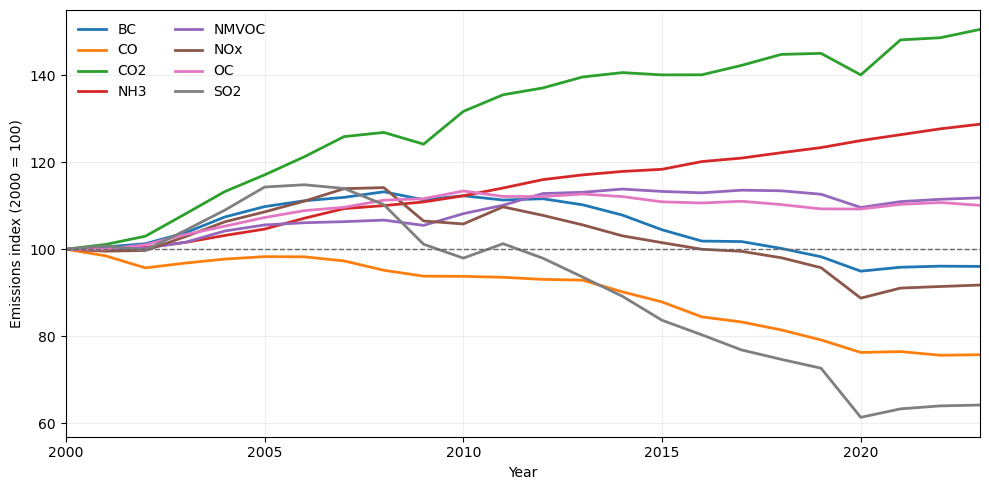

In [18]:
global_totals = (
    annual.groupby(["year", "species_variable"], as_index=False)["tg_yr"].sum()
    .sort_values(["species_variable", "year"])
)
print(global_totals[global_totals["year"].isin([2000, 2010, 2020, 2023])].to_string(index=False))

series = global_totals.pivot(index="year", columns="species_variable", values="tg_yr")
normalized = series.divide(series.loc[2000]).mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
for column in normalized.columns:
    ax.plot(normalized.index, normalized[column], linewidth=2, label=column)
ax.axhline(100, color="0.4", linestyle="--", linewidth=1)
ax.set(xlabel="Year", ylabel="Emissions index (2000 = 100)", xlim=(2000, 2023))
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)
fig.tight_layout()
plt.show()


## QA result summary

The archived files pass the metadata and aggregation checks, and the normalized trend plot confirms the baseline trajectory relative to 2000.


## Phase 0 checklist

- [x] verify old archive layout and file readability
- [x] confirm units and coordinate dimensions
- [x] aggregate global annual totals to Tg/yr
- [ ] compare with independent inventories before moving to production data
- [ ] proceed to the new production CEDS release


# Placeholder cell: formal inventory comparison is deferred until independent data are present.


In [11]:
# Independent inventory comparison is intentionally left as a placeholder until an external inventory table is available.


In [ ]:
# ## Quick intermediate cache

# # Create a compact saved table so the next round of analysis can start from the already-validated annual totals instead of re-running the full gridded aggregation.

# output_dir = PROJECT_ROOT / "output" / "preliminary"
# output_dir.mkdir(parents=True, exist_ok=True)

# annual_global = annual.rename(columns={"tg_yr": "tg_yr"}).copy()
# annual_global.to_csv(output_dir / "ceds_old_2000_2023_annual_global.csv", index=False)
# global_totals.to_csv(output_dir / "ceds_old_2000_2023_key_species_global.csv", index=False)
# normalized.reset_index().rename_axis("year").to_csv(output_dir / "ceds_old_2000_2023_normalized_index.csv", index=False)

# summary = pd.DataFrame({
#     "n_files": [len(selected)],
#     "n_species": [len(global_totals["species_variable"].unique())],
#     "year_min": [int(annual["year"].min())],
#     "year_max": [int(annual["year"].max())],
# })
# summary.to_csv(output_dir / "ceds_old_2000_2023_summary.csv", index=False)

# print(f"Saved intermediate outputs to {output_dir}")
# print(summary.to_string(index=False))
